Esercizio: implementa un loop di training completo per un modello lineare PyTorch che deve imparare la funzione y=2x. Definisci un input casuale, azzera i gradienti, calcola l'errore MSE, eseguila backpropgation e aggiorna i pesi per 50 opoche

In [1]:
%matplotlib inline

In [15]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

CREAZIONE DEI DATI

In [16]:
torch.manual_seed(42)

# 200 righe, 1 feature
X = torch.randn(200,1) * 5

# relazione lineare + rumore
y = 2 * X + torch.randn(200,1) * 2

GRAFICO INIZIALE (per capire la natura del problema)

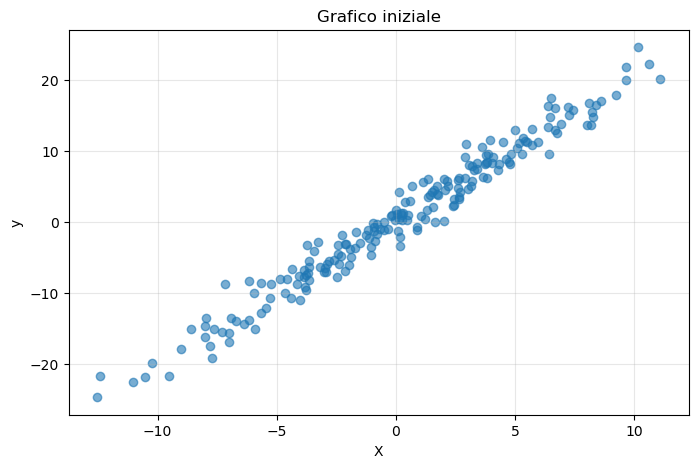

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(
    X.numpy().ravel(),
    y.numpy().ravel(),
    alpha=0.6
)

plt.title("Grafico iniziale")
plt.xlabel("X")
plt.ylabel("y")

plt.grid(True, alpha=0.3)

plt.show()

Il grafico suggerisce un problema lineare

TRAIN TEST SPLIT

In [ ]:
# sklearn usa NUMPY. Quindi convertiamo da Torch a NumPy
X_np = X.numpy()
y_np = y.numpy()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_np,
    y_np,
    test_size=0.2,
    random_state=42
)

REGRESSIONE LINEARE CON SKLEARN

In [19]:
lin_model = LinearRegression()

lin_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
#predizioni

y_pred_sklearn = lin_model.predict(X_test)

In [22]:
#metriche

mse = mean_squared_error(y_test, y_pred_sklearn)
r2 = r2_score(y_test, y_pred_sklearn)

print("=== SKLEARN ===")
print("Coefficiente:", lin_model.coef_.ravel()[0])
print("Bias:", lin_model.intercept_.ravel()[0])
print("MSE:", mse)
print("R2:", r2)

=== SKLEARN ===
Coefficiente: 2.030631
Bias: 0.29448208
MSE: 2.3905253410339355
R2: 0.9754265546798706


GRAFICO SKLEARN

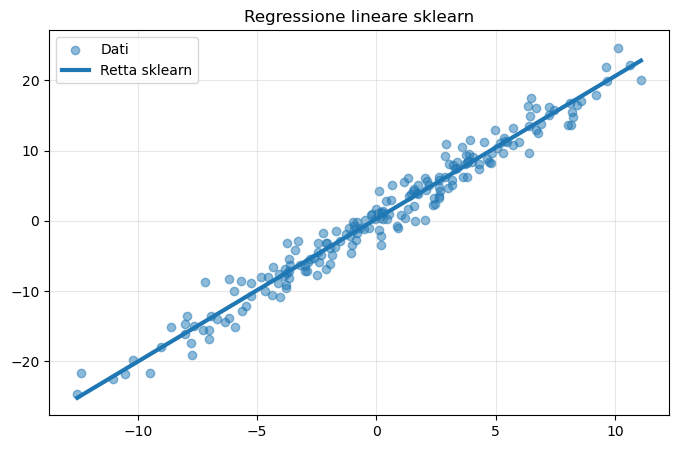

In [23]:
X_line = np.linspace(
    X_np.min(),
    X_np.max(),
    200
).reshape(-1,1)

y_line = lin_model.predict(X_line)

plt.figure(figsize=(8,5))

plt.scatter(
    X_np.ravel(),
    y_np.ravel(),
    alpha=0.5,
    label="Dati"
)

plt.plot(
    X_line.ravel(),
    y_line.ravel(),
    linewidth=3,
    label="Retta sklearn"
)

plt.legend()

plt.title("Regressione lineare sklearn")

plt.grid(True, alpha=0.3)

plt.show()

PYTORCH LINEARE
ora stesso cosa con pytorch

In [24]:
#conversione numpy -> tensor

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

MODELLO LINEARE PYTORCH

In [25]:
class LinearNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.linear = nn.Linear(1,1)

    def forward(self, x):

        return self.linear(x)

In [26]:
#creazione modello
model_linear = LinearNet()

#Loss
model_linear = LinearNet()

#Optimizer
criterion = nn.MSELoss()

#training
epochs = 50

for epoch in range(epochs):

    model_linear.train()

    optimizer.zero_grad()

    preds = model_linear(X_train_t)

    loss = criterion(preds, y_train_t)

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 100 == 0:

        print(
            f"Epoca {epoch+1} | Loss: {loss.item():.4f}"
        )

c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([160])) that is different to the input size (torch.Size([160, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


VALUTAZIONE MODELLO

In [27]:
model_linear.eval()

with torch.no_grad():

    y_pred_torch = model_linear(X_test_t)

In [28]:
#metriche

mse_torch = mean_squared_error(
    y_test,
    y_pred_torch.numpy()
)

r2_torch = r2_score(
    y_test,
    y_pred_torch.numpy()
)

print("=== PYTORCH LINEARE ===")

print(
    "Peso:",
    model_linear.linear.weight.item()
)

print(
    "Bias:",
    model_linear.linear.bias.item()
)

print("MSE:", mse_torch)

print("R2:", r2_torch)

=== PYTORCH LINEARE ===
Peso: -0.796399712562561
Bias: 0.632017970085144
MSE: 195.8719940185547
R2: -1.013467788696289


MODELLO DEEP LEARNING
rete esagerata

In [29]:
class DeepNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(1,64)

        self.fc2 = nn.Linear(64,32)

        self.out = nn.Linear(32,1)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.fc1(x))

        x = self.relu(self.fc2(x))

        return self.out(x)

TRAINING DEEP LEARNING

In [30]:
model_deep = DeepNet()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model_deep.parameters(),
    lr=0.01
)

epochs = 500

for epoch in range(epochs):

    model_deep.train()

    optimizer.zero_grad()

    preds = model_deep(X_train_t)

    loss = criterion(preds, y_train_t)

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 100 == 0:

        print(
            f"Epoca {epoch+1} | Loss: {loss.item():.4f}"
        )

c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([160])) that is different to the input size (torch.Size([160, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoca 100 | Loss: 101.3581
Epoca 200 | Loss: 101.3581
Epoca 300 | Loss: 101.3581
Epoca 400 | Loss: 101.3580
Epoca 500 | Loss: 101.3580


VALUTAZIONE DEEP LEARNING

In [31]:
model_deep.eval()

with torch.no_grad():

    y_pred_deep = model_deep(X_test_t)

In [32]:
#metriche

mse_deep = mean_squared_error(
    y_test,
    y_pred_deep.numpy()
)

r2_deep = r2_score(
    y_test,
    y_pred_deep.numpy()
)

print("=== PYTORCH DEEP ===")

print("MSE:", mse_deep)

print("R2:", r2_deep)

=== PYTORCH DEEP ===
MSE: 101.52041625976562
R2: -0.043579936027526855
